In [103]:
# Using pip
!pip install multiprocessing



  Using cached multiprocessing-2.6.2.1.tar.gz (108 kB)
  Preparing metadata (setup.py) ... error
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [7 lines of output]
      Traceback (most recent call last):
        File "<string>", line 2, in <module>
        File "<pip-setuptools-caller>", line 35, in <module>
        File "/private/var/folders/jm/7vmlf0cj3hqfx63tjv7bwkzr0000gn/T/pip-install-uurx2hxc/multiprocessing_2bb19d7cd4694a86a133d04dbdd19f75/setup.py", line 94
          print 'Macros:'
          ^^^^^^^^^^^^^^^
      SyntaxError: Missing parentheses in call to 'print'. Did you mean print(...)?
      [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for detail

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing
import os

import lightgbm as lgb
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import optuna
import shap
shap.initjs()

In [2]:
project_path ="/Volumes/Work/datascience/data science/projects/"

In [7]:
df_data = pd.read_csv(project_path+"dataprocessing/time_series/store-sales-time-series-forecasting/store_sales_time_series.csv")

/var/folders/jm/7vmlf0cj3hqfx63tjv7bwkzr0000gn/T/ipykernel_6566/2061782799.py:1: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_data = pd.read_csv(project_path+"dataprocessing/time_series/store-sales-time-series-forecasting/store_sales_time_series.csv")


In [25]:
df_data.head(10)

,store_nbr,family,sales,onpromotion,type,holiday,locale,oil_price,oilprice_linear,oilprice_spline,pay_day,day_sin,day_cos,month_sin,month_cos,days_since_start
0,1,AUTOMOTIVE,0.0,0,D,NaN,NaN,NaN,93.14,93.14,0,0.201299,0.97953,0.5,0.866025,0
1,1,BABY CARE,0.0,0,D,NaN,NaN,NaN,93.14,93.14,0,0.201299,0.97953,0.5,0.866025,0
2,1,BEAUTY,0.0,0,D,NaN,NaN,NaN,93.14,93.14,0,0.201299,0.97953,0.5,0.866025,0
3,1,BEVERAGES,0.0,0,D,NaN,NaN,NaN,93.14,93.14,0,0.201299,0.97953,0.5,0.866025,0
4,1,BOOKS,0.0,0,D,NaN,NaN,NaN,93.14,93.14,0,0.201299,0.97953,0.5,0.866025,0
5,1,BREAD/BAKERY,0.0,0,D,NaN,NaN,NaN,93.14,93.14,0,0.201299,0.97953,0.5,0.866025,0
6,1,CELEBRATION,0.0,0,D,NaN,NaN,NaN,93.14,93.14,0,0.201299,0.97953,0.5,0.866025,0
7,1,CLEANING,0.0,0,D,NaN,NaN,NaN,93.14,93.14,0,0.201299,0.97953,0.5,0.866025,0
8,1,DAIRY,0.0,0,D,NaN,NaN,NaN,93.14,93.14,0,0.201299,0.97953,0.5,0.866025,0
9,1,DELI,0.0,0,D,NaN,NaN,NaN,93.14,93.14,0,0.201299,0.97953,0.5,0.866025,0


In [8]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3001152 entries, 0 to 3001151
Data columns (total 16 columns):
 #   Column            Dtype  
---  ------            -----  
 0   store_nbr         int64  
 1   family            object 
 2   sales             float64
 3   onpromotion       int64  
 4   type              object 
 5   holiday           object 
 6   locale            object 
 7   oil_price         float64
 8   oilprice_linear   float64
 9   oilprice_spline   float64
 10  pay_day           int64  
 11  day_sin           float64
 12  day_cos           float64
 13  month_sin         float64
 14  month_cos         float64
 15  days_since_start  int64  
dtypes: float64(8), int64(4), object(4)
memory usage: 366.4+ MB


We have 14 feature columns with a mixture of numerical and categorical data and around 3 million rows. Sales is a continuous variable, therefore we have a regression in hand.

Lets build a LightGBM regressor as the baseline model.
Why LightGBM?
- Handles large datasets effeciently
- Native handling of ctegorical variables ( no need for one-hot encoding)
- can model non-linear relationships and interactions between features, promotion, holidays with sales.
- suport early stopping for fast experimentation

## LightGBM

In [26]:
df_lgb = df_data.copy(deep=True)
target = 'sales'

# features to drop

drop_cols = [
    target,
    "oilprice_spline",
    "oilprice_linear"
]

# define categorical columns

categorical_feat = [
    "store_nbr","family","type","holiday","locale"
]

for col in categorical_feat:
    df_lgb[col] = df_lgb[col].astype("category")

max_day = df_lgb["days_since_start"].max()
val_set_start = max_day - 60

# Train and validation split
df_train_lgb = df_lgb[df_lgb["days_since_start"] <= val_set_start]
df_val_lgb = df_lgb[df_lgb["days_since_start"] > val_set_start]

X_train = df_train_lgb.drop(columns=drop_cols)
Y_train = df_train_lgb[target]
X_val = df_val_lgb.drop(columns=drop_cols)
Y_val = df_val_lgb[target]



In [87]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2844336 entries, 49896 to 2894099
Data columns (total 22 columns):
 #   Column              Dtype   
---  ------              -----   
 0   store_nbr           category
 1   family              category
 2   onpromotion         int64   
 3   type                category
 4   holiday             category
 5   locale              category
 6   oil_price           float64 
 7   pay_day             int64   
 8   day_sin             float64 
 9   day_cos             float64 
 10  month_sin           float64 
 11  month_cos           float64 
 12  days_since_start    int64   
 13  sales_lag_1         float64 
 14  sales_lag_7         float64 
 15  sales_lag_14        float64 
 16  sales_roll_mean_7   float64 
 17  sales_roll_mean_14  float64 
 18  sales_roll_mean_28  float64 
 19  sales_roll_std_7    float64 
 20  sales_roll_std_14   float64 
 21  sales_roll_std_28   float64 
dtypes: category(5), float64(14), int64(3)
memory usage: 404.2 MB


In [27]:
# Create LightGBM. dataset

lgb_train = lgb.Dataset(X_train, label=Y_train, categorical_feature=categorical_feat)
lgb_val = lgb.Dataset(X_val,label=Y_val,categorical_feature=categorical_feat)

# LightGBM parameters

params = {
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves" : 64,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbose":-1,
}

model = lgb.train(
    params,
    lgb_train,
    valid_sets = [lgb_train, lgb_val],
    valid_names=["train","val"],
    num_boost_round = 2000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=50)  # print every 50 rounds
    ]
)


Training until validation scores don't improve for 100 rounds
[50]	train's rmse: 345.816	val's rmse: 338.885
[100]	train's rmse: 288.105	val's rmse: 312.285
[150]	train's rmse: 266.928	val's rmse: 308.834
[200]	train's rmse: 255.08	val's rmse: 306.991
[250]	train's rmse: 248.137	val's rmse: 309.139
[300]	train's rmse: 241.96	val's rmse: 309.729
Early stopping, best iteration is:
[222]	train's rmse: 251.892	val's rmse: 306.524


Validation RMSE 303.6195


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

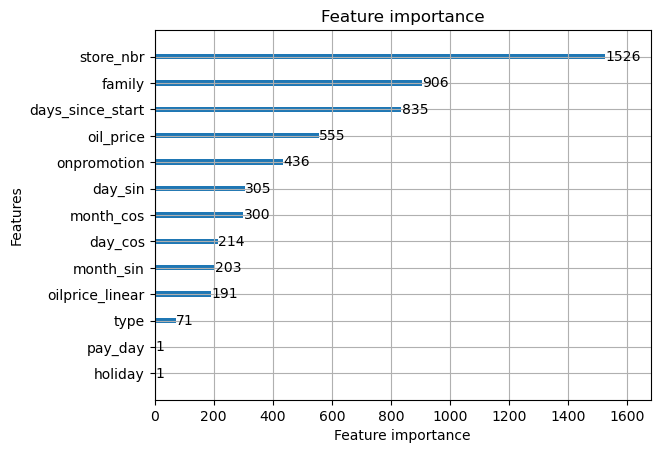

In [ ]:
### THis is using oilprice linear dont touch this 

# Evaluate

y_pred = model.predict(X_val,num_iteration=model.best_iteration)
rmse = np.sqrt(mean_squared_error(Y_val,y_pred))
print(f"Validation RMSE {rmse:.4f}")

#Feature importance
lgb.plot_importance(model,max_num_features=20)

Validation RMSE 306.5244
['store_nbr', 'family', 'onpromotion', 'type', 'holiday', 'locale', 'oil_price', 'pay_day', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'days_since_start']
[3604 2085 1271   83   23    1 1441   50 1070  712  638  723 2285]


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

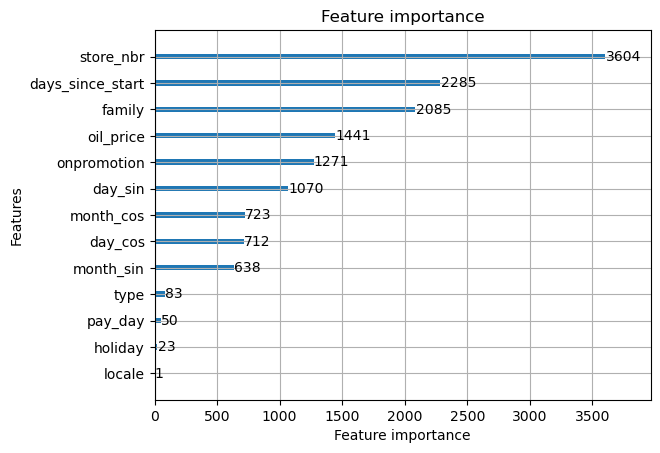

In [30]:
## This is using oil price spline.
# Evaluate

y_pred = model.predict(X_val,num_iteration=model.best_iteration)
rmse = np.sqrt(mean_squared_error(Y_val,y_pred))
print(f"Validation RMSE {rmse:.4f}")

#Feature importance
print(model.feature_name())
print(model.feature_importance())
lgb.plot_importance(model,max_num_features=20)

### Adding lag effects


In a time series analysis since our goal is to capture future trends, it is fair to assume i have the past sales data, in principle til the previous day.
Therefore lets add a new column which captures the sales of previous days

In [33]:
# Sorting for lag calculation
df_lgb_lag = df_lgb.sort_values(['store_nbr','family','days_since_start'])
new_features = []
# Lag features from previous sales
lag_window = [1,7,14]
for lag in lag_window:
    df_lgb_lag[f"sales_lag_{lag}"] = df_lgb_lag.groupby(['store_nbr','family'])['sales'].shift(lag)
    new_features.append(f"sales_lag_{lag}")

# Rolling mean features
rolling_window = [7,14,28]
for window in rolling_window:
    df_lgb_lag[f"sales_roll_mean_{window}"] = (
        df_lgb_lag.groupby(['store_nbr','family'])['sales']
        .shift(1)
        .rolling(window=window)
        .mean()
    )
    new_features.append(f"sales_roll_mean_{window}")

# Rolling std features
for window in rolling_window:
    df_lgb_lag[f"sales_roll_std_{window}"] = (
        df_lgb_lag.groupby(["store_nbr","family"])['sales']
        .shift(1)
        .rolling(window=window)
        .std()
    )
    new_features.append(f"sales_roll_std_{window}")

df_lgb_lag = df_lgb_lag.dropna(subset=new_features)

/var/folders/jm/7vmlf0cj3hqfx63tjv7bwkzr0000gn/T/ipykernel_6566/1727134597.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_lgb_lag[f"sales_lag_{lag}"] = df_lgb_lag.groupby(['store_nbr','family'])['sales'].shift(lag)
/var/folders/jm/7vmlf0cj3hqfx63tjv7bwkzr0000gn/T/ipykernel_6566/1727134597.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_lgb_lag[f"sales_lag_{lag}"] = df_lgb_lag.groupby(['store_nbr','family'])['sales'].shift(lag)
/var/folders/jm/7vmlf0cj3hqfx63tjv7bwkzr0000gn/T/ipykernel_6566/1727134597.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in

In [127]:
df_lgb_lag_train = df_lgb_lag[df_lgb_lag['days_since_start'] <= val_set_start]
df_lgb_lag_val = df_lgb_lag[df_lgb_lag["days_since_start"] > val_set_start]

X_train = df_lgb_lag_train.drop(columns=drop_cols)
y_train = df_lgb_lag_train[target]
X_val = df_lgb_lag_val.drop(columns=drop_cols)
y_val = df_lgb_lag_val[target]

lgb_lag_train = lgb.Dataset(X_train, label= y_train, categorical_feature=categorical_feat)
lgb_lag_val = lgb.Dataset(X_val, label=y_val, categorical_feature=categorical_feat)

model_lag = lgb.train(
    params,
    lgb_lag_train,
    valid_sets = [lgb_lag_train, lgb_lag_val],
    valid_names=["train","val"],
    num_boost_round = 2000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=50)  # print every 50 rounds
    ]
)

Training until validation scores don't improve for 100 rounds
[50]	train's rmse: 272.126	val's rmse: 241.696
[100]	train's rmse: 233.07	val's rmse: 232.455
[150]	train's rmse: 220.509	val's rmse: 239.081
Early stopping, best iteration is:
[76]	train's rmse: 244.338	val's rmse: 227.431


[352 114 371   0   9   1 418   7 421 412  83 254 232 634 510 410 304  28
  42  92  60  34]
['store_nbr', 'family', 'onpromotion', 'type', 'holiday', 'locale', 'oil_price', 'pay_day', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'days_since_start', 'sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_roll_mean_7', 'sales_roll_mean_14', 'sales_roll_mean_28', 'sales_roll_std_7', 'sales_roll_std_14', 'sales_roll_std_28']


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

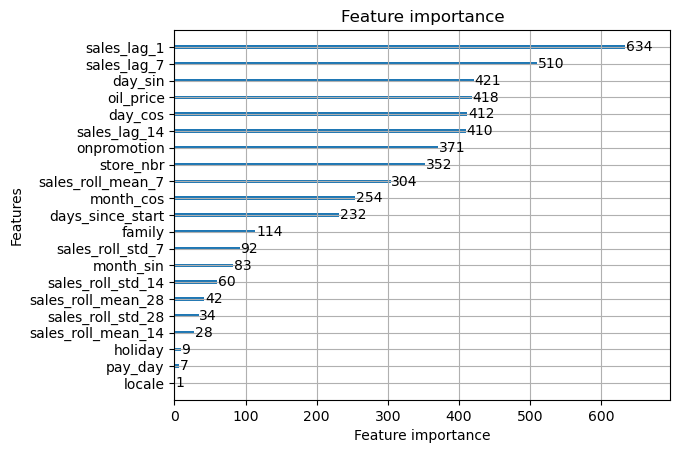

In [47]:
print(model_lag.feature_importance())
print(model_lag.feature_name())
lgb.plot_importance(model_lag,max_num_features=30)

In [50]:
X_train

,store_nbr,family,onpromotion,type,holiday,locale,oil_price,pay_day,day_sin,day_cos,...,days_since_start,sales_lag_1,sales_lag_7,sales_lag_14,sales_roll_mean_7,sales_roll_mean_14,sales_roll_mean_28,sales_roll_std_7,sales_roll_std_14,sales_roll_std_28
49896,1,AUTOMOTIVE,0,D,NaN,NaN,97.62,0,-3.943559e-01,0.918958,...,28,3.0,1.0,1.0,2.571429,2.142857,2.142857,1.718249,1.703261,1.458418
51678,1,AUTOMOTIVE,0,D,NaN,NaN,97.98,0,-2.012985e-01,0.979530,...,29,2.0,3.0,1.0,2.714286,2.214286,2.214286,1.603567,1.672335,1.397276
53460,1,AUTOMOTIVE,0,D,NaN,NaN,97.65,1,-2.449294e-16,1.000000,...,30,6.0,0.0,1.0,3.142857,2.571429,2.357143,2.035401,1.910066,1.568540
55242,1,AUTOMOTIVE,0,D,NaN,NaN,97.46,0,2.012985e-01,0.979530,...,31,0.0,5.0,0.0,3.142857,2.500000,2.250000,2.035401,1.990361,1.624466
57024,1,AUTOMOTIVE,0,D,NaN,NaN,NaN,0,3.943559e-01,0.918958,...,32,3.0,4.0,5.0,2.857143,2.714286,2.250000,1.864454,1.857565,1.624466
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2886971,54,SEAFOOD,0,C,NaN,NaN,46.10,0,6.513725e-01,-0.758758,...,1623,2.0,3.0,7.0,2.714286,2.928571,3.142857,1.799470,2.400778,2.592215
2888753,54,SEAFOOD,0,C,NaN,NaN,46.41,0,4.853020e-01,-0.874347,...,1624,5.0,4.0,1.0,3.000000,2.785714,3.000000,2.000000,2.190137,2.357023
2890535,54,SEAFOOD,0,C,NaN,NaN,44.79,0,2.993631e-01,-0.954139,...,1625,0.0,0.0,7.0,2.428571,2.714286,2.857143,2.225394,2.267787,2.414682
2892317,54,SEAFOOD,0,C,NaN,NaN,44.47,1,1.011683e-01,-0.994869,...,1626,3.0,5.0,0.0,2.857143,2.428571,2.892857,1.951800,1.910066,2.408923


In [64]:
# Create a SHAP explainer for your trained LightGBM model
explainer = shap.TreeExplainer(model_lag)

# Calculate SHAP values on your validation set
shap_values = explainer.shap_values(X_val)

importance = np.abs(shap_values).mean(axis=0)

# Create a DataFrame for easy viewing
shap_importance = pd.DataFrame({
    "feature": X_val.columns,
    "importance": importance
}).sort_values(by="importance", ascending=False)

print(shap_importance)

               feature  importance
16   sales_roll_mean_7  264.166473
13         sales_lag_1  154.813222
14         sales_lag_7  126.468752
15        sales_lag_14   44.216784
6            oil_price   16.153130
2          onpromotion   11.362998
9              day_cos    8.189069
18  sales_roll_mean_28    7.603868
17  sales_roll_mean_14    6.115060
0            store_nbr    5.777380
8              day_sin    4.238824
1               family    3.195788
12    days_since_start    1.722727
11           month_cos    1.512231
19    sales_roll_std_7    1.296985
20   sales_roll_std_14    1.032034
21   sales_roll_std_28    0.660924
10           month_sin    0.536056
7              pay_day    0.017399
4              holiday    0.015392
5               locale    0.002108
3                 type    0.000000


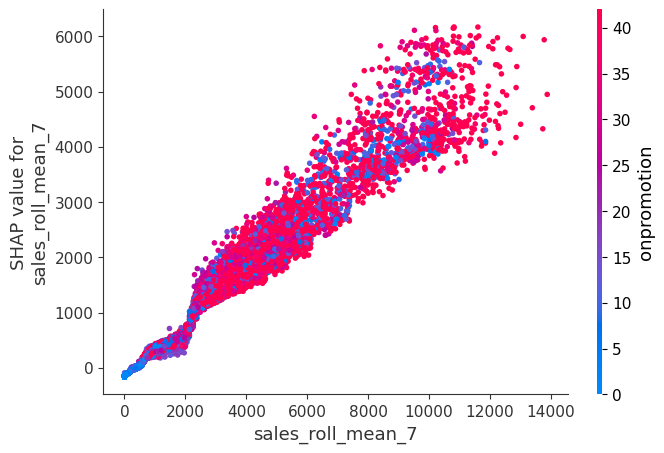

In [65]:
shap.dependence_plot("sales_roll_mean_7", shap_values, X_val, interaction_index="onpromotion")
# explainer.shap_values(X_train)

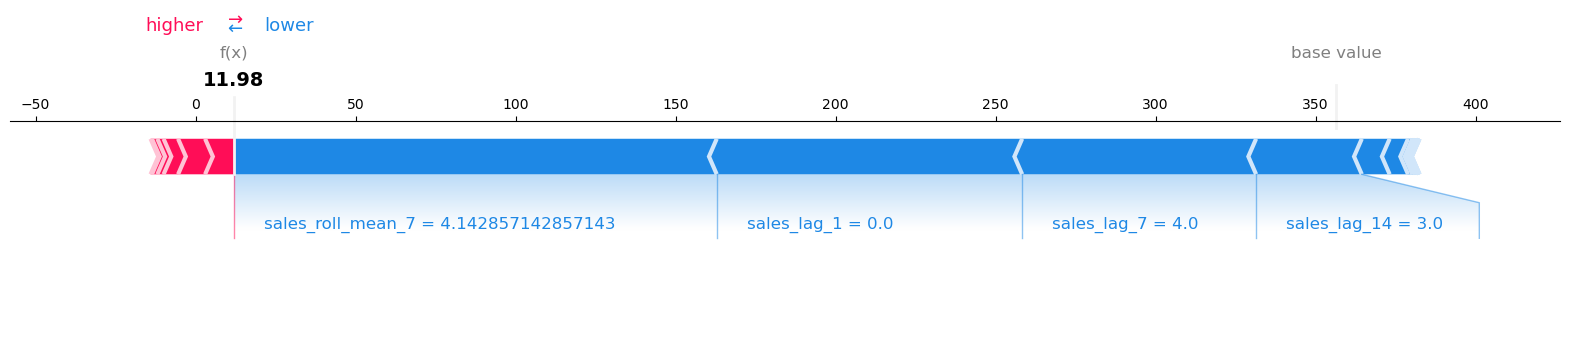

In [72]:
i=17
shap.force_plot(explainer.expected_value, shap_values[i], X_val.iloc[i],matplotlib=True)


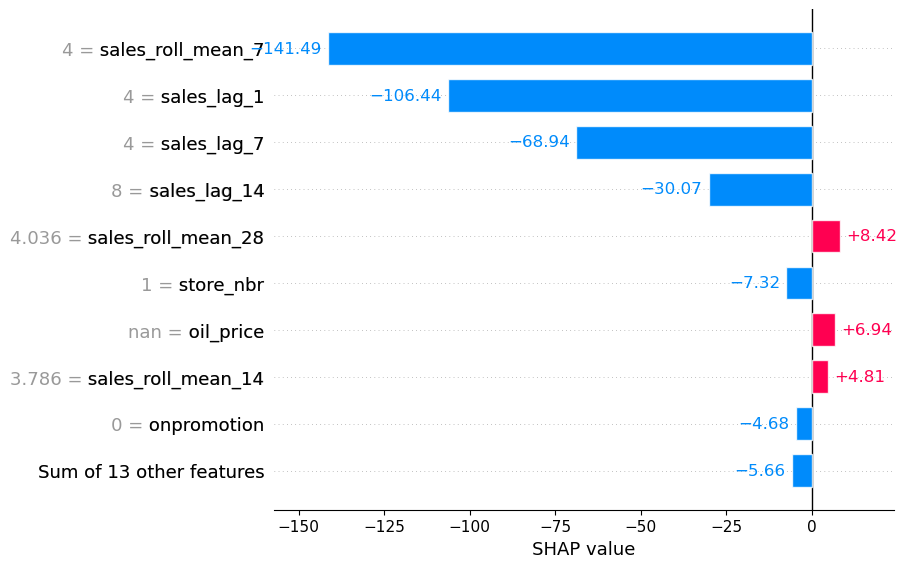

In [ ]:
explainer = shap.Explainer(model_lag)
shap_values = explainer(X_val)



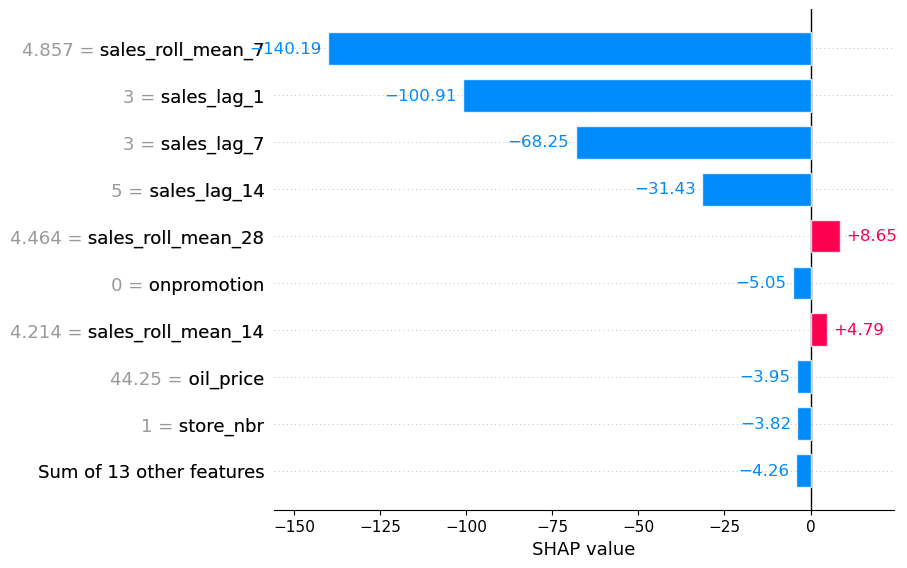

In [83]:
# visualize the first prediction's explanation
shap.plots.bar(shap_values[10])

Since we have categorical features which are not converted to numerical. Plotting them to understand feature interaction is a bit tricky. Lets put this on hold for the time being.
From this exercise we do understnd the engineered lag features play an important role in predicting the future sales.

Now lets get on with fine tuning the model.

### Fine tuning

In [177]:
total_cores = multiprocessing.cpu_count()
half_cores = max(1, total_cores //2) 

X_train_opt, X_val_opt, y_train_opt, y_val_opt = train_test_split(
    X_train, y_train, test_size=0.4,random_state=40
)

# lgb_opt_train = lgb.Dataset(X_train_opt,label=y_train_opt, categorical_feature=categorical_feat)
# lgb_opt_val = lgb.Dataset(X_val_opt, label=y_val_opt,categorical_feature=categorical_feat)
trial_results = []

def objective(trial):
    params = {
        "objective": "regression",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "device": "cpu",
        "num_threads": half_cores,
        "verbosity": -1,
        "seed": 20,
        # "feature_pre_filter":False,
        "num_leaves": trial.suggest_int("num_leaves",31,512),
        "max_depth": trial.suggest_int("max_depth",-1,16),
        "learning_rate": trial.suggest_float("learning_rate",0.005, 0.3, log=True),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 20, 200),
        "lambda_l1": trial.suggest_float("lambda_l1", 0.0, 5.0),
        "lambda_l2": trial.suggest_float("lambda_l2", 0.0, 5.0),
    }

    model =lgb.train(
        params,
        lgb_lag_train,
        valid_sets=[lgb_lag_val],
        num_boost_round= 5000,
        callbacks=[
            lgb.early_stopping(stopping_rounds=200)
        ]
    )

    rmse = model.best_score["valid_0"]["rmse"]
    trial_results.append({"trial":trial.number,"rmse":rmse,**params})
    
    return model.best_score["valid_0"]["rmse"]

# Running optuna
study_lag_1 = optuna.create_study(direction="minimize")
study_lag_1.optimize(objective, n_trials=50)

results_df = pd.DataFrame(trial_results)
print("Best params from Global search:", study_lag_1.best_trial.params)
print("Best RMSE value",study_lag_1.best_trial.value)

[I 2025-08-14 10:43:14,629] A new study created in memory with name: no-name-55754509-a1d5-44f2-a527-795fe7d24170


Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:43:28,339] Trial 0 finished with value: 224.5972081057418 and parameters: {'num_leaves': 199, 'max_depth': 6, 'learning_rate': 0.03654376312708766, 'feature_fraction': 0.8585728210030075, 'bagging_fraction': 0.8389685864784034, 'bagging_freq': 3, 'min_data_in_leaf': 70, 'lambda_l1': 2.6695560199043618, 'lambda_l2': 4.200277416273482}. Best is trial 0 with value: 224.5972081057418.


Early stopping, best iteration is:
[128]	valid_0's rmse: 224.597
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:43:39,248] Trial 1 finished with value: 226.28701625464672 and parameters: {'num_leaves': 40, 'max_depth': 8, 'learning_rate': 0.03786093082165977, 'feature_fraction': 0.9410036462023501, 'bagging_fraction': 0.9060660150179861, 'bagging_freq': 3, 'min_data_in_leaf': 110, 'lambda_l1': 0.8562931112133909, 'lambda_l2': 0.09598214535746996}. Best is trial 0 with value: 224.5972081057418.


Early stopping, best iteration is:
[119]	valid_0's rmse: 226.287
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:43:50,731] Trial 2 finished with value: 223.54125101632138 and parameters: {'num_leaves': 113, 'max_depth': -1, 'learning_rate': 0.02102130270255436, 'feature_fraction': 0.9693812035891917, 'bagging_fraction': 0.9254992867314942, 'bagging_freq': 1, 'min_data_in_leaf': 162, 'lambda_l1': 2.4193395719475026, 'lambda_l2': 3.8663716897875666}. Best is trial 2 with value: 223.54125101632138.


Early stopping, best iteration is:
[188]	valid_0's rmse: 223.541
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:44:03,226] Trial 3 finished with value: 227.11992125904132 and parameters: {'num_leaves': 453, 'max_depth': 5, 'learning_rate': 0.0665713787646034, 'feature_fraction': 0.7770086741095407, 'bagging_fraction': 0.9902179796401899, 'bagging_freq': 2, 'min_data_in_leaf': 130, 'lambda_l1': 4.542721381455891, 'lambda_l2': 2.9737858552394387}. Best is trial 2 with value: 223.54125101632138.


Early stopping, best iteration is:
[104]	valid_0's rmse: 227.12
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:44:22,080] Trial 4 finished with value: 223.00561158925024 and parameters: {'num_leaves': 172, 'max_depth': 7, 'learning_rate': 0.03228748394551265, 'feature_fraction': 0.8050106549883115, 'bagging_fraction': 0.998449382076372, 'bagging_freq': 2, 'min_data_in_leaf': 78, 'lambda_l1': 0.5655417822295228, 'lambda_l2': 2.3567961457037367}. Best is trial 4 with value: 223.00561158925024.


Early stopping, best iteration is:
[126]	valid_0's rmse: 223.006
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:44:35,415] Trial 5 finished with value: 224.27298023448304 and parameters: {'num_leaves': 118, 'max_depth': 6, 'learning_rate': 0.04755361589422347, 'feature_fraction': 0.6008435699296379, 'bagging_fraction': 0.7874041752180211, 'bagging_freq': 5, 'min_data_in_leaf': 47, 'lambda_l1': 1.0606866992397253, 'lambda_l2': 1.984142382204019}. Best is trial 4 with value: 223.00561158925024.


Early stopping, best iteration is:
[98]	valid_0's rmse: 224.273
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:45:15,832] Trial 6 finished with value: 220.92732619659066 and parameters: {'num_leaves': 170, 'max_depth': 10, 'learning_rate': 0.0063835365969403465, 'feature_fraction': 0.8832281529519033, 'bagging_fraction': 0.7181511812807352, 'bagging_freq': 6, 'min_data_in_leaf': 136, 'lambda_l1': 3.5736033314567655, 'lambda_l2': 4.127972054772774}. Best is trial 6 with value: 220.92732619659066.


Early stopping, best iteration is:
[595]	valid_0's rmse: 220.927
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:45:42,722] Trial 7 finished with value: 219.40632858378635 and parameters: {'num_leaves': 503, 'max_depth': 14, 'learning_rate': 0.042806598005870125, 'feature_fraction': 0.7748640376085233, 'bagging_fraction': 0.8149581025641937, 'bagging_freq': 2, 'min_data_in_leaf': 186, 'lambda_l1': 4.370379747563207, 'lambda_l2': 1.1654029411578748}. Best is trial 7 with value: 219.40632858378635.


Early stopping, best iteration is:
[79]	valid_0's rmse: 219.406
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:46:03,611] Trial 8 finished with value: 219.57972360511212 and parameters: {'num_leaves': 428, 'max_depth': 9, 'learning_rate': 0.03256193570004811, 'feature_fraction': 0.9952920709644643, 'bagging_fraction': 0.7708665162340224, 'bagging_freq': 9, 'min_data_in_leaf': 61, 'lambda_l1': 3.61956814043139, 'lambda_l2': 2.165369180798289}. Best is trial 7 with value: 219.40632858378635.


Early stopping, best iteration is:
[123]	valid_0's rmse: 219.58
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:46:32,017] Trial 9 finished with value: 224.20120097569128 and parameters: {'num_leaves': 250, 'max_depth': 6, 'learning_rate': 0.009400139404244865, 'feature_fraction': 0.8642594602550722, 'bagging_fraction': 0.7050800358830508, 'bagging_freq': 9, 'min_data_in_leaf': 71, 'lambda_l1': 4.645647445953348, 'lambda_l2': 1.3457242212518727}. Best is trial 7 with value: 219.40632858378635.


Early stopping, best iteration is:
[556]	valid_0's rmse: 224.201
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:46:50,516] Trial 10 finished with value: 224.16421996422432 and parameters: {'num_leaves': 357, 'max_depth': 16, 'learning_rate': 0.21611909421541403, 'feature_fraction': 0.6826627248503283, 'bagging_fraction': 0.6096533835221746, 'bagging_freq': 6, 'min_data_in_leaf': 200, 'lambda_l1': 2.1283922107784896, 'lambda_l2': 0.41641752531821075}. Best is trial 7 with value: 219.40632858378635.


Early stopping, best iteration is:
[16]	valid_0's rmse: 224.164
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:47:10,169] Trial 11 finished with value: 223.4831101586775 and parameters: {'num_leaves': 511, 'max_depth': 14, 'learning_rate': 0.10602817868289309, 'feature_fraction': 0.7266311329104584, 'bagging_fraction': 0.7788321216021239, 'bagging_freq': 10, 'min_data_in_leaf': 24, 'lambda_l1': 3.81320222008326, 'lambda_l2': 1.1876495257748116}. Best is trial 7 with value: 219.40632858378635.


Early stopping, best iteration is:
[33]	valid_0's rmse: 223.483
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:47:46,254] Trial 12 finished with value: 220.3561638394713 and parameters: {'num_leaves': 381, 'max_depth': 12, 'learning_rate': 0.016993690158577202, 'feature_fraction': 0.7731640670323354, 'bagging_fraction': 0.8476939731079018, 'bagging_freq': 8, 'min_data_in_leaf': 191, 'lambda_l1': 3.5091279833965707, 'lambda_l2': 2.9814936553490674}. Best is trial 7 with value: 219.40632858378635.


Early stopping, best iteration is:
[236]	valid_0's rmse: 220.356
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:47:55,471] Trial 13 finished with value: 239.45969242926952 and parameters: {'num_leaves': 398, 'max_depth': 2, 'learning_rate': 0.09984963645731648, 'feature_fraction': 0.9899994487013656, 'bagging_fraction': 0.7218953705184241, 'bagging_freq': 8, 'min_data_in_leaf': 98, 'lambda_l1': 4.852576613472595, 'lambda_l2': 1.3598772163121384}. Best is trial 7 with value: 219.40632858378635.


Early stopping, best iteration is:
[403]	valid_0's rmse: 239.46
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:48:33,756] Trial 14 finished with value: 219.46367496504723 and parameters: {'num_leaves': 512, 'max_depth': 11, 'learning_rate': 0.015469661350238863, 'feature_fraction': 0.6858281058900931, 'bagging_fraction': 0.6422321834263881, 'bagging_freq': 5, 'min_data_in_leaf': 166, 'lambda_l1': 4.192370698386836, 'lambda_l2': 4.980779169303599}. Best is trial 7 with value: 219.40632858378635.


Early stopping, best iteration is:
[239]	valid_0's rmse: 219.464
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:49:15,772] Trial 15 finished with value: 220.89304438775125 and parameters: {'num_leaves': 511, 'max_depth': 12, 'learning_rate': 0.01345911862372159, 'feature_fraction': 0.6592802133364282, 'bagging_fraction': 0.6033909030930902, 'bagging_freq': 4, 'min_data_in_leaf': 169, 'lambda_l1': 4.108665913286521, 'lambda_l2': 4.649559725516033}. Best is trial 7 with value: 219.40632858378635.


Early stopping, best iteration is:
[279]	valid_0's rmse: 220.893
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:50:09,836] Trial 16 finished with value: 220.44732993177823 and parameters: {'num_leaves': 321, 'max_depth': 16, 'learning_rate': 0.006358365366720686, 'feature_fraction': 0.7183260037109385, 'bagging_fraction': 0.667097697511895, 'bagging_freq': 5, 'min_data_in_leaf': 166, 'lambda_l1': 2.9994192036541367, 'lambda_l2': 3.110600985931428}. Best is trial 7 with value: 219.40632858378635.


Early stopping, best iteration is:
[604]	valid_0's rmse: 220.447
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:50:19,379] Trial 17 finished with value: 226.59163144911795 and parameters: {'num_leaves': 472, 'max_depth': 12, 'learning_rate': 0.28482302950092625, 'feature_fraction': 0.6418307953780267, 'bagging_fraction': 0.8502250686111605, 'bagging_freq': 1, 'min_data_in_leaf': 141, 'lambda_l1': 1.9504969188357704, 'lambda_l2': 0.6490444751037003}. Best is trial 7 with value: 219.40632858378635.


Early stopping, best iteration is:
[10]	valid_0's rmse: 226.592
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:50:46,855] Trial 18 finished with value: 222.89616888545584 and parameters: {'num_leaves': 308, 'max_depth': 14, 'learning_rate': 0.02257508111882085, 'feature_fraction': 0.7973966044463335, 'bagging_fraction': 0.6552542295561257, 'bagging_freq': 7, 'min_data_in_leaf': 179, 'lambda_l1': 4.981631315434936, 'lambda_l2': 4.903947675755429}. Best is trial 7 with value: 219.40632858378635.


Early stopping, best iteration is:
[162]	valid_0's rmse: 222.896
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:51:32,904] Trial 19 finished with value: 221.0854973898356 and parameters: {'num_leaves': 456, 'max_depth': 10, 'learning_rate': 0.010985258655206845, 'feature_fraction': 0.7287956439755926, 'bagging_fraction': 0.9000033260343145, 'bagging_freq': 4, 'min_data_in_leaf': 149, 'lambda_l1': 4.142950008736016, 'lambda_l2': 3.6516592340950327}. Best is trial 7 with value: 219.40632858378635.


Early stopping, best iteration is:
[332]	valid_0's rmse: 221.085
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:51:54,849] Trial 20 finished with value: 218.66887431835255 and parameters: {'num_leaves': 414, 'max_depth': 14, 'learning_rate': 0.06450800339591657, 'feature_fraction': 0.6918113166235264, 'bagging_fraction': 0.7496288203294982, 'bagging_freq': 4, 'min_data_in_leaf': 120, 'lambda_l1': 1.6197320408981228, 'lambda_l2': 1.7833423460009632}. Best is trial 20 with value: 218.66887431835255.


Early stopping, best iteration is:
[60]	valid_0's rmse: 218.669
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:52:16,748] Trial 21 finished with value: 219.25978520404618 and parameters: {'num_leaves': 487, 'max_depth': 14, 'learning_rate': 0.06749275703881771, 'feature_fraction': 0.6941858589347754, 'bagging_fraction': 0.7520752052541323, 'bagging_freq': 4, 'min_data_in_leaf': 110, 'lambda_l1': 1.472532035768364, 'lambda_l2': 1.7818402859292612}. Best is trial 20 with value: 218.66887431835255.


Early stopping, best iteration is:
[50]	valid_0's rmse: 219.26
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:52:37,586] Trial 22 finished with value: 220.6259902060314 and parameters: {'num_leaves': 414, 'max_depth': 14, 'learning_rate': 0.07964575280810843, 'feature_fraction': 0.747295496945292, 'bagging_fraction': 0.738737939398628, 'bagging_freq': 3, 'min_data_in_leaf': 112, 'lambda_l1': 1.445959332271459, 'lambda_l2': 1.7926565582417806}. Best is trial 20 with value: 218.66887431835255.


Early stopping, best iteration is:
[43]	valid_0's rmse: 220.626
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:52:59,487] Trial 23 finished with value: 222.24971085102146 and parameters: {'num_leaves': 464, 'max_depth': 15, 'learning_rate': 0.15481269098128048, 'feature_fraction': 0.6102123883215937, 'bagging_fraction': 0.8125137144134065, 'bagging_freq': 4, 'min_data_in_leaf': 94, 'lambda_l1': 1.5598031200461357, 'lambda_l2': 0.8731774171348952}. Best is trial 20 with value: 218.66887431835255.


Early stopping, best iteration is:
[21]	valid_0's rmse: 222.25
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:53:21,920] Trial 24 finished with value: 220.4779929181957 and parameters: {'num_leaves': 356, 'max_depth': 13, 'learning_rate': 0.05531706777622501, 'feature_fraction': 0.692384173597459, 'bagging_fraction': 0.7544912680032292, 'bagging_freq': 2, 'min_data_in_leaf': 120, 'lambda_l1': 0.03701012806425452, 'lambda_l2': 1.7000875321750906}. Best is trial 20 with value: 218.66887431835255.


Early stopping, best iteration is:
[72]	valid_0's rmse: 220.478
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:53:43,909] Trial 25 finished with value: 223.3710963169095 and parameters: {'num_leaves': 431, 'max_depth': 16, 'learning_rate': 0.1417467862686529, 'feature_fraction': 0.8224499972305889, 'bagging_fraction': 0.8150670992684672, 'bagging_freq': 3, 'min_data_in_leaf': 89, 'lambda_l1': 1.7604685829804119, 'lambda_l2': 2.6251166324112942}. Best is trial 20 with value: 218.66887431835255.


Early stopping, best iteration is:
[25]	valid_0's rmse: 223.371
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:54:03,794] Trial 26 finished with value: 219.31841648685133 and parameters: {'num_leaves': 479, 'max_depth': 13, 'learning_rate': 0.07510812575645293, 'feature_fraction': 0.749283003133742, 'bagging_fraction': 0.688803824496443, 'bagging_freq': 4, 'min_data_in_leaf': 150, 'lambda_l1': 1.227398070595993, 'lambda_l2': 0.9570590910247296}. Best is trial 20 with value: 218.66887431835255.


Early stopping, best iteration is:
[51]	valid_0's rmse: 219.318
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:54:20,717] Trial 27 finished with value: 220.6509645481659 and parameters: {'num_leaves': 284, 'max_depth': 11, 'learning_rate': 0.07885648469232806, 'feature_fraction': 0.6442956634427786, 'bagging_fraction': 0.6895457483650143, 'bagging_freq': 4, 'min_data_in_leaf': 125, 'lambda_l1': 1.1141363065437893, 'lambda_l2': 1.6411882798809065}. Best is trial 20 with value: 218.66887431835255.


Early stopping, best iteration is:
[48]	valid_0's rmse: 220.651
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:54:37,486] Trial 28 finished with value: 221.16903776525325 and parameters: {'num_leaves': 374, 'max_depth': 13, 'learning_rate': 0.12687195728601677, 'feature_fraction': 0.7080153251192289, 'bagging_fraction': 0.6785652326998347, 'bagging_freq': 6, 'min_data_in_leaf': 153, 'lambda_l1': 1.4361075982717406, 'lambda_l2': 0.8350753981668391}. Best is trial 20 with value: 218.66887431835255.


Early stopping, best iteration is:
[26]	valid_0's rmse: 221.169
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:55:01,324] Trial 29 finished with value: 220.1605563877866 and parameters: {'num_leaves': 481, 'max_depth': 15, 'learning_rate': 0.060623953513369445, 'feature_fraction': 0.7522073255170868, 'bagging_fraction': 0.758028403708327, 'bagging_freq': 5, 'min_data_in_leaf': 103, 'lambda_l1': 2.848559432997538, 'lambda_l2': 2.6433969811075717}. Best is trial 20 with value: 218.66887431835255.


Early stopping, best iteration is:
[58]	valid_0's rmse: 220.161
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:55:15,132] Trial 30 finished with value: 222.14374382637286 and parameters: {'num_leaves': 233, 'max_depth': 9, 'learning_rate': 0.07324961310452349, 'feature_fraction': 0.667602289541015, 'bagging_fraction': 0.6356471812924183, 'bagging_freq': 3, 'min_data_in_leaf': 83, 'lambda_l1': 0.5890448785139097, 'lambda_l2': 2.0161220740810077}. Best is trial 20 with value: 218.66887431835255.


Early stopping, best iteration is:
[47]	valid_0's rmse: 222.144
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:55:39,595] Trial 31 finished with value: 219.97664908538482 and parameters: {'num_leaves': 480, 'max_depth': 13, 'learning_rate': 0.04485598520322391, 'feature_fraction': 0.7565906873763725, 'bagging_fraction': 0.7395370739250657, 'bagging_freq': 2, 'min_data_in_leaf': 185, 'lambda_l1': 2.4383629662537403, 'lambda_l2': 1.1297577572524644}. Best is trial 20 with value: 218.66887431835255.


Early stopping, best iteration is:
[79]	valid_0's rmse: 219.977
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:56:08,624] Trial 32 finished with value: 220.62688409917203 and parameters: {'num_leaves': 440, 'max_depth': 15, 'learning_rate': 0.028932661640732354, 'feature_fraction': 0.8249582751314768, 'bagging_fraction': 0.8069270780281539, 'bagging_freq': 4, 'min_data_in_leaf': 115, 'lambda_l1': 2.170163201018104, 'lambda_l2': 1.4034148580426624}. Best is trial 20 with value: 218.66887431835255.


Early stopping, best iteration is:
[120]	valid_0's rmse: 220.627
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:56:24,898] Trial 33 finished with value: 219.09306151880787 and parameters: {'num_leaves': 487, 'max_depth': 14, 'learning_rate': 0.04203329487017067, 'feature_fraction': 0.9109032015621912, 'bagging_fraction': 0.8290476779640408, 'bagging_freq': 1, 'min_data_in_leaf': 148, 'lambda_l1': 1.1864896720151923, 'lambda_l2': 0.22958401127581973}. Best is trial 20 with value: 218.66887431835255.


Early stopping, best iteration is:
[83]	valid_0's rmse: 219.093
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:56:34,360] Trial 34 finished with value: 220.7308661225273 and parameters: {'num_leaves': 406, 'max_depth': 11, 'learning_rate': 0.1078297193772152, 'feature_fraction': 0.9321645871464804, 'bagging_fraction': 0.8814508059786339, 'bagging_freq': 1, 'min_data_in_leaf': 146, 'lambda_l1': 0.689524683595903, 'lambda_l2': 0.11513235404646957}. Best is trial 20 with value: 218.66887431835255.


Early stopping, best iteration is:
[32]	valid_0's rmse: 220.731
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:57:03,615] Trial 35 finished with value: 219.2784727401606 and parameters: {'num_leaves': 482, 'max_depth': -1, 'learning_rate': 0.05573986495710285, 'feature_fraction': 0.8850626987718796, 'bagging_fraction': 0.9553330356291156, 'bagging_freq': 3, 'min_data_in_leaf': 131, 'lambda_l1': 0.25817917312644045, 'lambda_l2': 0.39496175673584144}. Best is trial 20 with value: 218.66887431835255.


Early stopping, best iteration is:
[56]	valid_0's rmse: 219.278
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:57:21,138] Trial 36 finished with value: 231.95577625657168 and parameters: {'num_leaves': 433, 'max_depth': 3, 'learning_rate': 0.024681137180157728, 'feature_fraction': 0.8828883442870444, 'bagging_fraction': 0.9497697378773642, 'bagging_freq': 1, 'min_data_in_leaf': 107, 'lambda_l1': 0.2817495706790204, 'lambda_l2': 0.01896836755846537}. Best is trial 20 with value: 218.66887431835255.


Early stopping, best iteration is:
[898]	valid_0's rmse: 231.956
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:57:30,609] Trial 37 finished with value: 226.8786453017025 and parameters: {'num_leaves': 59, 'max_depth': -1, 'learning_rate': 0.05459901835123451, 'feature_fraction': 0.9441082399186483, 'bagging_fraction': 0.9674331544209969, 'bagging_freq': 3, 'min_data_in_leaf': 131, 'lambda_l1': 0.9284259849289684, 'lambda_l2': 0.575522924145464}. Best is trial 20 with value: 218.66887431835255.


Early stopping, best iteration is:
[67]	valid_0's rmse: 226.879
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:57:53,846] Trial 38 finished with value: 220.40186421976563 and parameters: {'num_leaves': 334, 'max_depth': 0, 'learning_rate': 0.04724343352048772, 'feature_fraction': 0.906165581299727, 'bagging_fraction': 0.8673997948323375, 'bagging_freq': 2, 'min_data_in_leaf': 124, 'lambda_l1': 0.3422946074038783, 'lambda_l2': 0.39451823104530703}. Best is trial 20 with value: 218.66887431835255.


Early stopping, best iteration is:
[72]	valid_0's rmse: 220.402
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:59:20,018] Trial 39 finished with value: 263.4425686495485 and parameters: {'num_leaves': 454, 'max_depth': 1, 'learning_rate': 0.03989668298398498, 'feature_fraction': 0.8486456590461359, 'bagging_fraction': 0.9246154581978048, 'bagging_freq': 3, 'min_data_in_leaf': 139, 'lambda_l1': 0.810692454751366, 'lambda_l2': 2.3780068350646637}. Best is trial 20 with value: 218.66887431835255.


Did not meet early stopping. Best iteration is:
[4896]	valid_0's rmse: 263.443
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:59:34,505] Trial 40 finished with value: 232.4299068003402 and parameters: {'num_leaves': 482, 'max_depth': 3, 'learning_rate': 0.03574786710674254, 'feature_fraction': 0.9215702602701337, 'bagging_fraction': 0.8340011558203758, 'bagging_freq': 1, 'min_data_in_leaf': 158, 'lambda_l1': 0.02500557752344812, 'lambda_l2': 0.3044549666031259}. Best is trial 20 with value: 218.66887431835255.


Early stopping, best iteration is:
[759]	valid_0's rmse: 232.43
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 10:59:53,639] Trial 41 finished with value: 219.0299844990401 and parameters: {'num_leaves': 483, 'max_depth': 13, 'learning_rate': 0.08458441415690188, 'feature_fraction': 0.8924375862194566, 'bagging_fraction': 0.7039821634249017, 'bagging_freq': 4, 'min_data_in_leaf': 135, 'lambda_l1': 1.1992117710709087, 'lambda_l2': 0.8570773072895588}. Best is trial 20 with value: 218.66887431835255.


Early stopping, best iteration is:
[41]	valid_0's rmse: 219.03
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 11:00:02,435] Trial 42 finished with value: 227.32501991967723 and parameters: {'num_leaves': 490, 'max_depth': 5, 'learning_rate': 0.09241580064125476, 'feature_fraction': 0.9575492518144085, 'bagging_fraction': 0.788506913235644, 'bagging_freq': 5, 'min_data_in_leaf': 131, 'lambda_l1': 1.2165653804641405, 'lambda_l2': 0.6072498200772585}. Best is trial 20 with value: 218.66887431835255.


Early stopping, best iteration is:
[77]	valid_0's rmse: 227.325
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 11:00:15,758] Trial 43 finished with value: 221.68462152835332 and parameters: {'num_leaves': 458, 'max_depth': 8, 'learning_rate': 0.060888187486842486, 'feature_fraction': 0.8959082721552781, 'bagging_fraction': 0.7145555400876592, 'bagging_freq': 3, 'min_data_in_leaf': 117, 'lambda_l1': 1.9263314920761276, 'lambda_l2': 0.7844416636821765}. Best is trial 20 with value: 218.66887431835255.


Early stopping, best iteration is:
[60]	valid_0's rmse: 221.685
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 11:00:35,771] Trial 44 finished with value: 223.0391137711092 and parameters: {'num_leaves': 411, 'max_depth': 15, 'learning_rate': 0.18465348372946888, 'feature_fraction': 0.8546150341291211, 'bagging_fraction': 0.7329327098192776, 'bagging_freq': 2, 'min_data_in_leaf': 135, 'lambda_l1': 1.6797589091726164, 'lambda_l2': 0.22756671429834666}. Best is trial 20 with value: 218.66887431835255.


Early stopping, best iteration is:
[19]	valid_0's rmse: 223.039
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 11:00:50,033] Trial 45 finished with value: 225.4820119477325 and parameters: {'num_leaves': 496, 'max_depth': 5, 'learning_rate': 0.030571107624615738, 'feature_fraction': 0.8754982629117067, 'bagging_fraction': 0.7536814821046199, 'bagging_freq': 6, 'min_data_in_leaf': 105, 'lambda_l1': 0.33763059252343064, 'lambda_l2': 1.4940682368680949}. Best is trial 20 with value: 218.66887431835255.


Early stopping, best iteration is:
[247]	valid_0's rmse: 225.482
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 11:01:03,193] Trial 46 finished with value: 223.64524355419312 and parameters: {'num_leaves': 444, 'max_depth': 7, 'learning_rate': 0.051669774639774416, 'feature_fraction': 0.9115043829578783, 'bagging_fraction': 0.7691230388415563, 'bagging_freq': 4, 'min_data_in_leaf': 127, 'lambda_l1': 0.9210742686738316, 'lambda_l2': 2.131860650403153}. Best is trial 20 with value: 218.66887431835255.


Early stopping, best iteration is:
[94]	valid_0's rmse: 223.645
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 11:01:20,550] Trial 47 finished with value: 221.52410451425717 and parameters: {'num_leaves': 392, 'max_depth': 10, 'learning_rate': 0.087670989974816, 'feature_fraction': 0.8364976265042423, 'bagging_fraction': 0.9830768315512453, 'bagging_freq': 3, 'min_data_in_leaf': 140, 'lambda_l1': 1.396204096214737, 'lambda_l2': 0.43900698068854616}. Best is trial 20 with value: 218.66887431835255.


Early stopping, best iteration is:
[39]	valid_0's rmse: 221.524
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 11:01:36,660] Trial 48 finished with value: 222.4578423555878 and parameters: {'num_leaves': 165, 'max_depth': 14, 'learning_rate': 0.06916671677581339, 'feature_fraction': 0.8022014242955288, 'bagging_fraction': 0.7920734795995302, 'bagging_freq': 5, 'min_data_in_leaf': 174, 'lambda_l1': 2.2590660109825027, 'lambda_l2': 1.0736404459050415}. Best is trial 20 with value: 218.66887431835255.


Early stopping, best iteration is:
[54]	valid_0's rmse: 222.458
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 11:01:55,458] Trial 49 finished with value: 220.09684260037173 and parameters: {'num_leaves': 497, 'max_depth': 12, 'learning_rate': 0.12055966281070075, 'feature_fraction': 0.973812515670505, 'bagging_fraction': 0.704054331682811, 'bagging_freq': 2, 'min_data_in_leaf': 55, 'lambda_l1': 1.8681146477493036, 'lambda_l2': 1.9452378455672539}. Best is trial 20 with value: 218.66887431835255.


Early stopping, best iteration is:
[30]	valid_0's rmse: 220.097
Best params from Global search: {'num_leaves': 414, 'max_depth': 14, 'learning_rate': 0.06450800339591657, 'feature_fraction': 0.6918113166235264, 'bagging_fraction': 0.7496288203294982, 'bagging_freq': 4, 'min_data_in_leaf': 120, 'lambda_l1': 1.6197320408981228, 'lambda_l2': 1.7833423460009632}
Best RMSE value 218.66887431835255


In [178]:
### Retraining on full dataset

params1 = study_lag_1.best_trial.params
params1.update({
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "device_type": "cpu",
    "seed": 20,
})

model_lag1 = lgb.train(
    params1,
    lgb_lag_train,
    valid_sets = [lgb_lag_train, lgb_lag_val],
    valid_names=["train","val"],
    num_boost_round = 5000,
    callbacks=[
        # lgb.early_stopping(stopping_rounds=200),
        lgb.log_evaluation(period=200)  # print every 50 rounds
    ]
)

[200]	train's rmse: 203.502	val's rmse: 227.973
[400]	train's rmse: 185.877	val's rmse: 232.61
[600]	train's rmse: 174.329	val's rmse: 235.452
[800]	train's rmse: 164.754	val's rmse: 239.72
[1000]	train's rmse: 157.083	val's rmse: 240.382
[1200]	train's rmse: 150.277	val's rmse: 242.374
[1400]	train's rmse: 143.835	val's rmse: 244.562
[1600]	train's rmse: 138.121	val's rmse: 245.845
[1800]	train's rmse: 132.75	val's rmse: 246.536
[2000]	train's rmse: 127.925	val's rmse: 247.702
[2200]	train's rmse: 123.312	val's rmse: 248.37
[2400]	train's rmse: 119.199	val's rmse: 249.688
[2600]	train's rmse: 115.247	val's rmse: 250.819
[2800]	train's rmse: 111.325	val's rmse: 251.275
[3000]	train's rmse: 107.615	val's rmse: 251.863
[3200]	train's rmse: 104.03	val's rmse: 252.594
[3400]	train's rmse: 100.626	val's rmse: 252.973
[3600]	train's rmse: 97.6613	val's rmse: 253.999
[3800]	train's rmse: 94.633	val's rmse: 254.781
[4000]	train's rmse: 91.96	val's rmse: 255.135
[4200]	train's rmse: 89.247	val'

What we see in the above cell is a classic example of over fitting. After the initial iteration though fit to training is improving, the valid set RMSE is getting worser. THis is beasically because of the param values 'num_leaves': 414, 'max_depth': 14, coming from fine tuning. Since we allow a larger range for num of leave nodes and depth, it is not a simple model. Keep in mind "The simplest model is always the most probable model" (Occum's razor).

Inorder to avoid this, we limit the range of hyper-parameters avoiding params supporting complex models.

In [174]:
# Cpu cores

total_cores = multiprocessing.cpu_count()
half_cores = max(1, total_cores //2) 

X_train_opt, X_val_opt, y_train_opt, y_val_opt = train_test_split(
    X_train, y_train, test_size=0.4,random_state=40
)

lgb_opt_train = lgb.Dataset(X_train_opt,label=y_train_opt, categorical_feature=categorical_feat)
lgb_opt_val = lgb.Dataset(X_val_opt, label=y_val_opt,categorical_feature=categorical_feat)

trial_results = []

def objective(trial):
    params = {
        "objective": "regression",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "device": "cpu",
        "num_threads": half_cores,
        "verbosity": -1,
        "seed": 20,
        # "feature_pre_filter":False,
        "num_leaves": trial.suggest_int("num_leaves",31,255),
        "max_depth": trial.suggest_int("max_depth",4,16),
        "learning_rate": trial.suggest_float("learning_rate",0.005, 0.1, log=True),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 50, 200),
        "lambda_l1": trial.suggest_float("lambda_l1", 0.0, 5.0),
        "lambda_l2": trial.suggest_float("lambda_l2", 0.0, 5.0),
    }

    model =lgb.train(
        params,
        lgb_lag_train,
        valid_sets=[lgb_lag_val],
        num_boost_round= 5000,
        callbacks=[
            lgb.early_stopping(stopping_rounds=200)
        ]
    )

    rmse = model.best_score["valid_0"]["rmse"]
    trial_results.append({"trial":trial.number,"rmse":rmse,**params})
    
    return model.best_score["valid_0"]["rmse"]

# Running optuna
study_lag = optuna.create_study(direction="minimize")
study_lag.optimize(objective, n_trials=50)

results_df = pd.DataFrame(trial_results)
print("Best params from Global search:", study_lag.best_trial.params)
print("Best RMSE value",study_lag.best_trial.value)

[I 2025-08-14 09:18:56,737] A new study created in memory with name: no-name-d24ba413-74f7-4e36-9c06-c46445391e79


Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:19:11,222] Trial 0 finished with value: 223.37323052781755 and parameters: {'num_leaves': 119, 'max_depth': 8, 'learning_rate': 0.05887939885349019, 'feature_fraction': 0.6217272919293607, 'bagging_fraction': 0.746635421208775, 'bagging_freq': 2, 'min_data_in_leaf': 95, 'lambda_l1': 1.8652065230002441, 'lambda_l2': 1.59752272145387}. Best is trial 0 with value: 223.37323052781755.


Early stopping, best iteration is:
[71]	valid_0's rmse: 223.373
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:19:31,217] Trial 1 finished with value: 223.5481758308553 and parameters: {'num_leaves': 243, 'max_depth': 9, 'learning_rate': 0.03269305556341917, 'feature_fraction': 0.8185746352425478, 'bagging_fraction': 0.9862580829525942, 'bagging_freq': 5, 'min_data_in_leaf': 160, 'lambda_l1': 0.44631360308184154, 'lambda_l2': 3.9817967455075514}. Best is trial 0 with value: 223.37323052781755.


Early stopping, best iteration is:
[105]	valid_0's rmse: 223.548
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:20:12,423] Trial 2 finished with value: 220.26380613630553 and parameters: {'num_leaves': 246, 'max_depth': 12, 'learning_rate': 0.007167393702931306, 'feature_fraction': 0.6650894740525201, 'bagging_fraction': 0.6873675373942087, 'bagging_freq': 6, 'min_data_in_leaf': 90, 'lambda_l1': 3.2234346103602607, 'lambda_l2': 4.019058574928279}. Best is trial 2 with value: 220.26380613630553.


Early stopping, best iteration is:
[515]	valid_0's rmse: 220.264
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:20:32,021] Trial 3 finished with value: 230.26225204817803 and parameters: {'num_leaves': 122, 'max_depth': 4, 'learning_rate': 0.014994243854161555, 'feature_fraction': 0.8511771822471602, 'bagging_fraction': 0.6431466996792359, 'bagging_freq': 4, 'min_data_in_leaf': 114, 'lambda_l1': 2.684686969483506, 'lambda_l2': 0.4840246393052239}. Best is trial 2 with value: 220.26380613630553.


Early stopping, best iteration is:
[627]	valid_0's rmse: 230.262
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:21:08,669] Trial 4 finished with value: 223.3824040045898 and parameters: {'num_leaves': 90, 'max_depth': 8, 'learning_rate': 0.006970981491135344, 'feature_fraction': 0.6629585928577424, 'bagging_fraction': 0.9226098661922375, 'bagging_freq': 6, 'min_data_in_leaf': 175, 'lambda_l1': 2.012050802406896, 'lambda_l2': 1.935939767890088}. Best is trial 2 with value: 220.26380613630553.


Early stopping, best iteration is:
[606]	valid_0's rmse: 223.382
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:21:22,311] Trial 5 finished with value: 224.90844881278645 and parameters: {'num_leaves': 70, 'max_depth': 13, 'learning_rate': 0.017608898807444633, 'feature_fraction': 0.913230874263355, 'bagging_fraction': 0.6665510212472536, 'bagging_freq': 6, 'min_data_in_leaf': 139, 'lambda_l1': 4.758349123513892, 'lambda_l2': 2.617315292053106}. Best is trial 2 with value: 220.26380613630553.


Early stopping, best iteration is:
[230]	valid_0's rmse: 224.908
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:21:33,912] Trial 6 finished with value: 226.04318926098628 and parameters: {'num_leaves': 32, 'max_depth': 6, 'learning_rate': 0.016619294244846577, 'feature_fraction': 0.8480265263057574, 'bagging_fraction': 0.6041757252263488, 'bagging_freq': 1, 'min_data_in_leaf': 63, 'lambda_l1': 3.5562128416298506, 'lambda_l2': 1.053358066952566}. Best is trial 2 with value: 220.26380613630553.


Early stopping, best iteration is:
[369]	valid_0's rmse: 226.043
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:22:05,802] Trial 7 finished with value: 222.2369317983756 and parameters: {'num_leaves': 140, 'max_depth': 12, 'learning_rate': 0.008547066508226668, 'feature_fraction': 0.962743868835956, 'bagging_fraction': 0.9661740140992345, 'bagging_freq': 2, 'min_data_in_leaf': 73, 'lambda_l1': 4.0473916509058885, 'lambda_l2': 2.0897563065136335}. Best is trial 2 with value: 220.26380613630553.


Early stopping, best iteration is:
[413]	valid_0's rmse: 222.237
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:22:42,853] Trial 8 finished with value: 223.93124833872116 and parameters: {'num_leaves': 77, 'max_depth': 11, 'learning_rate': 0.005587131392943562, 'feature_fraction': 0.6023216361621984, 'bagging_fraction': 0.71707828514332, 'bagging_freq': 10, 'min_data_in_leaf': 108, 'lambda_l1': 1.9021369300578272, 'lambda_l2': 0.31022971905796726}. Best is trial 2 with value: 220.26380613630553.


Early stopping, best iteration is:
[748]	valid_0's rmse: 223.931
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:22:55,807] Trial 9 finished with value: 222.46840479494492 and parameters: {'num_leaves': 183, 'max_depth': 14, 'learning_rate': 0.06642289976955384, 'feature_fraction': 0.6984983659865827, 'bagging_fraction': 0.9444887827246529, 'bagging_freq': 3, 'min_data_in_leaf': 68, 'lambda_l1': 3.0552935555435843, 'lambda_l2': 1.0825419487047772}. Best is trial 2 with value: 220.26380613630553.


Early stopping, best iteration is:
[55]	valid_0's rmse: 222.468
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:23:34,463] Trial 10 finished with value: 221.84620781949994 and parameters: {'num_leaves': 249, 'max_depth': 16, 'learning_rate': 0.009127715188644983, 'feature_fraction': 0.725334758847769, 'bagging_fraction': 0.8164775116768894, 'bagging_freq': 9, 'min_data_in_leaf': 196, 'lambda_l1': 0.4640913860976097, 'lambda_l2': 4.871675891674597}. Best is trial 2 with value: 220.26380613630553.


Early stopping, best iteration is:
[427]	valid_0's rmse: 221.846
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:24:09,957] Trial 11 finished with value: 221.3667741280578 and parameters: {'num_leaves': 254, 'max_depth': 16, 'learning_rate': 0.010464117941164497, 'feature_fraction': 0.7431339114189691, 'bagging_fraction': 0.8362178409563984, 'bagging_freq': 10, 'min_data_in_leaf': 196, 'lambda_l1': 0.03706649676722318, 'lambda_l2': 4.95781765509728}. Best is trial 2 with value: 220.26380613630553.


Early stopping, best iteration is:
[361]	valid_0's rmse: 221.367
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:24:39,693] Trial 12 finished with value: 221.81154533664008 and parameters: {'num_leaves': 202, 'max_depth': 16, 'learning_rate': 0.010420818528855095, 'feature_fraction': 0.7561421132219421, 'bagging_fraction': 0.8361651084947493, 'bagging_freq': 8, 'min_data_in_leaf': 139, 'lambda_l1': 1.1141114745185983, 'lambda_l2': 3.8787100788475}. Best is trial 2 with value: 220.26380613630553.


Early stopping, best iteration is:
[364]	valid_0's rmse: 221.812
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:24:58,349] Trial 13 finished with value: 221.7069214536054 and parameters: {'num_leaves': 207, 'max_depth': 14, 'learning_rate': 0.028982923253034625, 'feature_fraction': 0.7735211751376591, 'bagging_fraction': 0.8739932097212418, 'bagging_freq': 8, 'min_data_in_leaf': 92, 'lambda_l1': 4.028646900732285, 'lambda_l2': 4.964442319299028}. Best is trial 2 with value: 220.26380613630553.


Early stopping, best iteration is:
[123]	valid_0's rmse: 221.707
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:25:28,624] Trial 14 finished with value: 220.7774960752689 and parameters: {'num_leaves': 221, 'max_depth': 15, 'learning_rate': 0.012287732599812995, 'feature_fraction': 0.6695001737469048, 'bagging_fraction': 0.7626203329314242, 'bagging_freq': 7, 'min_data_in_leaf': 199, 'lambda_l1': 0.10435048850839124, 'lambda_l2': 3.771340116053839}. Best is trial 2 with value: 220.26380613630553.


Early stopping, best iteration is:
[301]	valid_0's rmse: 220.777
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:26:12,752] Trial 15 finished with value: 221.53162045210965 and parameters: {'num_leaves': 175, 'max_depth': 11, 'learning_rate': 0.0053623177981845325, 'feature_fraction': 0.6610526426118108, 'bagging_fraction': 0.7466354273139458, 'bagging_freq': 7, 'min_data_in_leaf': 50, 'lambda_l1': 1.26641831967478, 'lambda_l2': 3.2106489849877913}. Best is trial 2 with value: 220.26380613630553.


Early stopping, best iteration is:
[718]	valid_0's rmse: 221.532
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:26:36,012] Trial 16 finished with value: 221.00313954609047 and parameters: {'num_leaves': 224, 'max_depth': 14, 'learning_rate': 0.02489294895129522, 'feature_fraction': 0.6683151986558499, 'bagging_fraction': 0.705007932333267, 'bagging_freq': 7, 'min_data_in_leaf': 133, 'lambda_l1': 3.185195901069721, 'lambda_l2': 3.9410275455785784}. Best is trial 2 with value: 220.26380613630553.


Early stopping, best iteration is:
[162]	valid_0's rmse: 221.003
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:26:54,304] Trial 17 finished with value: 220.69504715167722 and parameters: {'num_leaves': 175, 'max_depth': 12, 'learning_rate': 0.04148927900425855, 'feature_fraction': 0.710313259940262, 'bagging_fraction': 0.7784579199771122, 'bagging_freq': 5, 'min_data_in_leaf': 167, 'lambda_l1': 4.9062857333767385, 'lambda_l2': 3.203934459491662}. Best is trial 2 with value: 220.26380613630553.


Early stopping, best iteration is:
[93]	valid_0's rmse: 220.695
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:27:10,349] Trial 18 finished with value: 221.4964815388759 and parameters: {'num_leaves': 164, 'max_depth': 10, 'learning_rate': 0.04293019124383842, 'feature_fraction': 0.7133454736586892, 'bagging_fraction': 0.6688479576322223, 'bagging_freq': 4, 'min_data_in_leaf': 157, 'lambda_l1': 4.492452445745947, 'lambda_l2': 3.0067415906892823}. Best is trial 2 with value: 220.26380613630553.


Early stopping, best iteration is:
[90]	valid_0's rmse: 221.496
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:27:27,091] Trial 19 finished with value: 221.65389744105306 and parameters: {'num_leaves': 154, 'max_depth': 12, 'learning_rate': 0.04296530316149833, 'feature_fraction': 0.7880139238714432, 'bagging_fraction': 0.7701351229580213, 'bagging_freq': 5, 'min_data_in_leaf': 169, 'lambda_l1': 4.905680504613345, 'lambda_l2': 3.2958593644957674}. Best is trial 2 with value: 220.26380613630553.


Early stopping, best iteration is:
[80]	valid_0's rmse: 221.654
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:27:42,838] Trial 20 finished with value: 220.47305050309458 and parameters: {'num_leaves': 200, 'max_depth': 10, 'learning_rate': 0.09460339880036671, 'feature_fraction': 0.6343365333647862, 'bagging_fraction': 0.8765929055219075, 'bagging_freq': 4, 'min_data_in_leaf': 85, 'lambda_l1': 3.875121965533943, 'lambda_l2': 4.504303067255772}. Best is trial 2 with value: 220.26380613630553.


Early stopping, best iteration is:
[39]	valid_0's rmse: 220.473
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:27:59,050] Trial 21 finished with value: 221.4588404921273 and parameters: {'num_leaves': 192, 'max_depth': 10, 'learning_rate': 0.07833504603513737, 'feature_fraction': 0.6271407336537007, 'bagging_fraction': 0.8873821439733967, 'bagging_freq': 4, 'min_data_in_leaf': 86, 'lambda_l1': 4.051909706611706, 'lambda_l2': 4.428092998284538}. Best is trial 2 with value: 220.26380613630553.


Early stopping, best iteration is:
[48]	valid_0's rmse: 221.459
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:28:15,242] Trial 22 finished with value: 223.1041850639752 and parameters: {'num_leaves': 221, 'max_depth': 12, 'learning_rate': 0.09755789213712827, 'feature_fraction': 0.6954884204287031, 'bagging_fraction': 0.7944486759006583, 'bagging_freq': 5, 'min_data_in_leaf': 114, 'lambda_l1': 3.563108568564653, 'lambda_l2': 4.3345749940079354}. Best is trial 2 with value: 220.26380613630553.


Early stopping, best iteration is:
[36]	valid_0's rmse: 223.104
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:28:33,751] Trial 23 finished with value: 220.8846540003345 and parameters: {'num_leaves': 236, 'max_depth': 9, 'learning_rate': 0.04960911974203762, 'feature_fraction': 0.6476460913397072, 'bagging_fraction': 0.8718792403115512, 'bagging_freq': 3, 'min_data_in_leaf': 84, 'lambda_l1': 4.295729319340982, 'lambda_l2': 3.563799520185866}. Best is trial 2 with value: 220.26380613630553.


Early stopping, best iteration is:
[79]	valid_0's rmse: 220.885
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:28:48,586] Trial 24 finished with value: 219.85501854634862 and parameters: {'num_leaves': 204, 'max_depth': 11, 'learning_rate': 0.09018068606626194, 'feature_fraction': 0.6943411930233021, 'bagging_fraction': 0.7072392622741992, 'bagging_freq': 6, 'min_data_in_leaf': 98, 'lambda_l1': 3.494615045279343, 'lambda_l2': 2.713613693219733}. Best is trial 24 with value: 219.85501854634862.


Early stopping, best iteration is:
[39]	valid_0's rmse: 219.855
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:28:59,728] Trial 25 finished with value: 223.0956560192715 and parameters: {'num_leaves': 205, 'max_depth': 7, 'learning_rate': 0.09867970528274639, 'feature_fraction': 0.6181629550191502, 'bagging_fraction': 0.7081279803752814, 'bagging_freq': 6, 'min_data_in_leaf': 102, 'lambda_l1': 3.5119770797850265, 'lambda_l2': 2.6890317511295825}. Best is trial 24 with value: 219.85501854634862.


Early stopping, best iteration is:
[59]	valid_0's rmse: 223.096
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:29:15,351] Trial 26 finished with value: 221.1623421043527 and parameters: {'num_leaves': 229, 'max_depth': 11, 'learning_rate': 0.07567236380507567, 'feature_fraction': 0.638250542511061, 'bagging_fraction': 0.630862959495043, 'bagging_freq': 8, 'min_data_in_leaf': 80, 'lambda_l1': 2.6358156097817096, 'lambda_l2': 4.281930677378669}. Best is trial 24 with value: 219.85501854634862.


Early stopping, best iteration is:
[48]	valid_0's rmse: 221.162
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:29:38,878] Trial 27 finished with value: 221.14929304330406 and parameters: {'num_leaves': 211, 'max_depth': 9, 'learning_rate': 0.0214495422473705, 'feature_fraction': 0.685098132402015, 'bagging_fraction': 0.6805074979868799, 'bagging_freq': 3, 'min_data_in_leaf': 123, 'lambda_l1': 3.1065608668521207, 'lambda_l2': 4.551765443230353}. Best is trial 24 with value: 219.85501854634862.


Early stopping, best iteration is:
[199]	valid_0's rmse: 221.149
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:29:49,211] Trial 28 finished with value: 225.04639078626775 and parameters: {'num_leaves': 192, 'max_depth': 6, 'learning_rate': 0.08096202243413755, 'feature_fraction': 0.7337907264904485, 'bagging_fraction': 0.9084313155743566, 'bagging_freq': 6, 'min_data_in_leaf': 53, 'lambda_l1': 2.2698046090871116, 'lambda_l2': 2.1790277370450197}. Best is trial 24 with value: 219.85501854634862.


Early stopping, best iteration is:
[56]	valid_0's rmse: 225.046
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:30:02,738] Trial 29 finished with value: 222.31387327808918 and parameters: {'num_leaves': 141, 'max_depth': 13, 'learning_rate': 0.06044342088825802, 'feature_fraction': 0.6017258975588378, 'bagging_fraction': 0.7404734276347257, 'bagging_freq': 4, 'min_data_in_leaf': 95, 'lambda_l1': 3.755425360660337, 'lambda_l2': 1.5745464313817221}. Best is trial 24 with value: 219.85501854634862.


Early stopping, best iteration is:
[65]	valid_0's rmse: 222.314
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:30:19,129] Trial 30 finished with value: 223.25226831540644 and parameters: {'num_leaves': 237, 'max_depth': 8, 'learning_rate': 0.05096482457307553, 'feature_fraction': 0.8204775004398166, 'bagging_fraction': 0.8428160207292604, 'bagging_freq': 2, 'min_data_in_leaf': 99, 'lambda_l1': 2.832517925118734, 'lambda_l2': 3.5347600656023}. Best is trial 24 with value: 219.85501854634862.


Early stopping, best iteration is:
[77]	valid_0's rmse: 223.252
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:30:34,309] Trial 31 finished with value: 220.93948097021072 and parameters: {'num_leaves': 170, 'max_depth': 11, 'learning_rate': 0.03632554150333595, 'feature_fraction': 0.7046389871816108, 'bagging_fraction': 0.781974678020904, 'bagging_freq': 5, 'min_data_in_leaf': 76, 'lambda_l1': 4.550378966459856, 'lambda_l2': 2.9895398358677268}. Best is trial 24 with value: 219.85501854634862.


Early stopping, best iteration is:
[96]	valid_0's rmse: 220.939
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:30:50,136] Trial 32 finished with value: 221.26766704839463 and parameters: {'num_leaves': 184, 'max_depth': 13, 'learning_rate': 0.06550248524202443, 'feature_fraction': 0.6426283680996349, 'bagging_fraction': 0.731162037651679, 'bagging_freq': 5, 'min_data_in_leaf': 120, 'lambda_l1': 4.984247260754966, 'lambda_l2': 2.8660718815645247}. Best is trial 24 with value: 219.85501854634862.


Early stopping, best iteration is:
[54]	valid_0's rmse: 221.268
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:31:05,107] Trial 33 finished with value: 220.31635160232275 and parameters: {'num_leaves': 157, 'max_depth': 10, 'learning_rate': 0.05252400643814415, 'feature_fraction': 0.7642744976649515, 'bagging_fraction': 0.802945016245544, 'bagging_freq': 7, 'min_data_in_leaf': 90, 'lambda_l1': 3.3376915143786827, 'lambda_l2': 4.079264598466572}. Best is trial 24 with value: 219.85501854634862.


Early stopping, best iteration is:
[74]	valid_0's rmse: 220.316
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:31:15,326] Trial 34 finished with value: 224.6834705520224 and parameters: {'num_leaves': 123, 'max_depth': 10, 'learning_rate': 0.09438622336397792, 'feature_fraction': 0.7594487881530222, 'bagging_fraction': 0.8088569974751902, 'bagging_freq': 7, 'min_data_in_leaf': 61, 'lambda_l1': 3.2969973760984272, 'lambda_l2': 4.044328997217532}. Best is trial 24 with value: 219.85501854634862.


Early stopping, best iteration is:
[39]	valid_0's rmse: 224.683
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:31:26,490] Trial 35 finished with value: 223.05659339179257 and parameters: {'num_leaves': 130, 'max_depth': 8, 'learning_rate': 0.08043342009174152, 'feature_fraction': 0.8125829821739541, 'bagging_fraction': 0.6886466840781967, 'bagging_freq': 6, 'min_data_in_leaf': 89, 'lambda_l1': 2.475536145392214, 'lambda_l2': 4.686959011583793}. Best is trial 24 with value: 219.85501854634862.


Early stopping, best iteration is:
[47]	valid_0's rmse: 223.057
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:31:40,478] Trial 36 finished with value: 221.47047562292988 and parameters: {'num_leaves': 154, 'max_depth': 9, 'learning_rate': 0.05335466940309708, 'feature_fraction': 0.676828871368864, 'bagging_fraction': 0.6434429400652233, 'bagging_freq': 7, 'min_data_in_leaf': 105, 'lambda_l1': 3.8202041746466096, 'lambda_l2': 4.119853393121608}. Best is trial 24 with value: 219.85501854634862.


Early stopping, best iteration is:
[79]	valid_0's rmse: 221.47
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:31:50,699] Trial 37 finished with value: 224.02311610065874 and parameters: {'num_leaves': 95, 'max_depth': 10, 'learning_rate': 0.06826733748317414, 'feature_fraction': 0.7909771591929978, 'bagging_fraction': 0.8592382341520303, 'bagging_freq': 6, 'min_data_in_leaf': 112, 'lambda_l1': 2.8608601483872107, 'lambda_l2': 3.7067683993492375}. Best is trial 24 with value: 219.85501854634862.


Early stopping, best iteration is:
[50]	valid_0's rmse: 224.023
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:32:14,622] Trial 38 finished with value: 225.0899361023524 and parameters: {'num_leaves': 155, 'max_depth': 7, 'learning_rate': 0.014193934856560434, 'feature_fraction': 0.9943391050770877, 'bagging_fraction': 0.614277959935236, 'bagging_freq': 9, 'min_data_in_leaf': 78, 'lambda_l1': 3.438024954831985, 'lambda_l2': 2.2985147726975654}. Best is trial 24 with value: 219.85501854634862.


Early stopping, best iteration is:
[368]	valid_0's rmse: 225.09
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:32:30,218] Trial 39 finished with value: 220.70104173622224 and parameters: {'num_leaves': 242, 'max_depth': 11, 'learning_rate': 0.02015666348241773, 'feature_fraction': 0.8981173394139321, 'bagging_fraction': 0.9307340666813588, 'bagging_freq': 1, 'min_data_in_leaf': 68, 'lambda_l1': 3.7840497099527597, 'lambda_l2': 1.426300509732092}. Best is trial 24 with value: 219.85501854634862.


Early stopping, best iteration is:
[181]	valid_0's rmse: 220.701
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:33:14,562] Trial 40 finished with value: 230.17752633408523 and parameters: {'num_leaves': 194, 'max_depth': 4, 'learning_rate': 0.006331119934059857, 'feature_fraction': 0.8634920667654968, 'bagging_fraction': 0.6497396597053655, 'bagging_freq': 4, 'min_data_in_leaf': 92, 'lambda_l1': 2.3570974251772805, 'lambda_l2': 4.681759932553633}. Best is trial 24 with value: 219.85501854634862.


Early stopping, best iteration is:
[1626]	valid_0's rmse: 230.178
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:33:32,675] Trial 41 finished with value: 221.23620842421022 and parameters: {'num_leaves': 179, 'max_depth': 12, 'learning_rate': 0.03409695796488105, 'feature_fraction': 0.7178167198395747, 'bagging_fraction': 0.7537601095286269, 'bagging_freq': 6, 'min_data_in_leaf': 149, 'lambda_l1': 4.283046181716226, 'lambda_l2': 3.293008181976481}. Best is trial 24 with value: 219.85501854634862.


Early stopping, best iteration is:
[105]	valid_0's rmse: 221.236
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:33:46,043] Trial 42 finished with value: 221.81380464392615 and parameters: {'num_leaves': 107, 'max_depth': 12, 'learning_rate': 0.04460042599778816, 'feature_fraction': 0.6905060091740749, 'bagging_fraction': 0.8192672061587805, 'bagging_freq': 5, 'min_data_in_leaf': 188, 'lambda_l1': 2.934268659403955, 'lambda_l2': 2.440586279099423}. Best is trial 24 with value: 219.85501854634862.


Early stopping, best iteration is:
[79]	valid_0's rmse: 221.814
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:34:03,156] Trial 43 finished with value: 223.08319331790918 and parameters: {'num_leaves': 160, 'max_depth': 13, 'learning_rate': 0.02906907912356698, 'feature_fraction': 0.7436015643369607, 'bagging_fraction': 0.991086617234264, 'bagging_freq': 4, 'min_data_in_leaf': 130, 'lambda_l1': 4.560729514590576, 'lambda_l2': 4.188293060687984}. Best is trial 24 with value: 219.85501854634862.


Early stopping, best iteration is:
[119]	valid_0's rmse: 223.083
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:34:21,974] Trial 44 finished with value: 220.63604788268228 and parameters: {'num_leaves': 214, 'max_depth': 10, 'learning_rate': 0.03757333399574239, 'feature_fraction': 0.6535061118823837, 'bagging_fraction': 0.7231433173959206, 'bagging_freq': 5, 'min_data_in_leaf': 99, 'lambda_l1': 4.001193069248696, 'lambda_l2': 1.858290608730094}. Best is trial 24 with value: 219.85501854634862.


Early stopping, best iteration is:
[101]	valid_0's rmse: 220.636
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:34:38,034] Trial 45 finished with value: 220.29765264754758 and parameters: {'num_leaves': 215, 'max_depth': 10, 'learning_rate': 0.057165074459305916, 'feature_fraction': 0.655225430868155, 'bagging_fraction': 0.6889609361614643, 'bagging_freq': 8, 'min_data_in_leaf': 97, 'lambda_l1': 3.3063124179210615, 'lambda_l2': 1.098287297980153}. Best is trial 24 with value: 219.85501854634862.


Early stopping, best iteration is:
[69]	valid_0's rmse: 220.298
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:34:45,481] Trial 46 finished with value: 227.9922251193837 and parameters: {'num_leaves': 36, 'max_depth': 9, 'learning_rate': 0.08811285344417767, 'feature_fraction': 0.6199670106677352, 'bagging_fraction': 0.6958450300337392, 'bagging_freq': 9, 'min_data_in_leaf': 70, 'lambda_l1': 3.269526826419529, 'lambda_l2': 0.6253930148522597}. Best is trial 24 with value: 219.85501854634862.


Early stopping, best iteration is:
[103]	valid_0's rmse: 227.992
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:35:02,571] Trial 47 finished with value: 220.6931528950173 and parameters: {'num_leaves': 250, 'max_depth': 11, 'learning_rate': 0.05907270658492573, 'feature_fraction': 0.6292382409186075, 'bagging_fraction': 0.6580504456162608, 'bagging_freq': 8, 'min_data_in_leaf': 107, 'lambda_l1': 3.572812471606557, 'lambda_l2': 0.8179335697325922}. Best is trial 24 with value: 219.85501854634862.


Early stopping, best iteration is:
[68]	valid_0's rmse: 220.693
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:35:17,576] Trial 48 finished with value: 220.27800891763042 and parameters: {'num_leaves': 232, 'max_depth': 11, 'learning_rate': 0.06920963772741485, 'feature_fraction': 0.6598328975783252, 'bagging_fraction': 0.6232411937224097, 'bagging_freq': 8, 'min_data_in_leaf': 81, 'lambda_l1': 2.1060435336241934, 'lambda_l2': 1.370956117734703}. Best is trial 24 with value: 219.85501854634862.


Early stopping, best iteration is:
[51]	valid_0's rmse: 220.278
Training until validation scores don't improve for 200 rounds


[I 2025-08-14 09:35:53,542] Trial 49 finished with value: 220.49340574247634 and parameters: {'num_leaves': 234, 'max_depth': 11, 'learning_rate': 0.007969736605208092, 'feature_fraction': 0.6788034208892284, 'bagging_fraction': 0.6223382362258293, 'bagging_freq': 8, 'min_data_in_leaf': 62, 'lambda_l1': 2.146486022929967, 'lambda_l2': 1.8937260960065987}. Best is trial 24 with value: 219.85501854634862.


Early stopping, best iteration is:
[473]	valid_0's rmse: 220.493
Best params from Global search: {'num_leaves': 204, 'max_depth': 11, 'learning_rate': 0.09018068606626194, 'feature_fraction': 0.6943411930233021, 'bagging_fraction': 0.7072392622741992, 'bagging_freq': 6, 'min_data_in_leaf': 98, 'lambda_l1': 3.494615045279343, 'lambda_l2': 2.713613693219733}
Best RMSE value 219.85501854634862


In [175]:
print(study_lag.best_trials)

[FrozenTrial(number=24, state=TrialState.COMPLETE, values=[219.85501854634862], datetime_start=datetime.datetime(2025, 8, 14, 9, 28, 33, 751831), datetime_complete=datetime.datetime(2025, 8, 14, 9, 28, 48, 586167), params={'num_leaves': 204, 'max_depth': 11, 'learning_rate': 0.09018068606626194, 'feature_fraction': 0.6943411930233021, 'bagging_fraction': 0.7072392622741992, 'bagging_freq': 6, 'min_data_in_leaf': 98, 'lambda_l1': 3.494615045279343, 'lambda_l2': 2.713613693219733}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'num_leaves': IntDistribution(high=255, log=False, low=31, step=1), 'max_depth': IntDistribution(high=16, log=False, low=4, step=1), 'learning_rate': FloatDistribution(high=0.1, log=True, low=0.005, step=None), 'feature_fraction': FloatDistribution(high=1.0, log=False, low=0.6, step=None), 'bagging_fraction': FloatDistribution(high=1.0, log=False, low=0.6, step=None), 'bagging_freq': IntDistribution(high=10, log=False, low=1, step=1), 'min_

In [176]:
### Retraining on full dataset

final_params = study_lag.best_trial.params
final_params.update({
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "device_type": "cpu",
    "seed": 20,
})

final_model_lag = lgb.train(
    final_params,
    lgb_lag_train,
    valid_sets = [lgb_lag_train, lgb_lag_val],
    valid_names=["train","val"],
    num_boost_round = 5000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=200),
        lgb.log_evaluation(period=200)  # print every 50 rounds
    ]
)

Training until validation scores don't improve for 200 rounds
[200]	train's rmse: 201.969	val's rmse: 234.736
Early stopping, best iteration is:
[39]	train's rmse: 246.628	val's rmse: 219.855


RMSE : 218.32926922590468


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

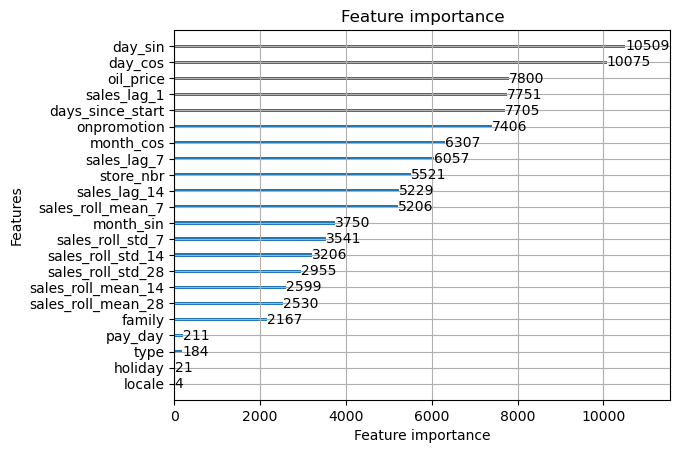

In [173]:
y_pred = final_model_lag.predict(X_val,num_iteration=final_model_lag.best_iteration)
rmse = np.sqrt(mean_squared_error(y_val,y_pred))
print("RMSE :",rmse)
lgb.plot_importance(final_model_lag,max_num_features=30)

In [131]:
print(final_model_lag.params)
print(model_lag.params)

{'num_leaves': 107, 'max_depth': 13, 'learning_rate': 0.02601473686201081, 'feature_fraction': 0.6957644276402909, 'bagging_fraction': 0.9179493850222004, 'bagging_freq': 9, 'min_data_in_leaf': 20, 'lambda_l1': 1.022531087867823, 'lambda_l2': 3.450870491563258, 'objective': 'regression', 'metric': 'rmse', 'boosting_type': 'gbdt', 'device_type': 'cpu', 'num_threads': 5, 'seed': 20, 'num_iterations': 50000, 'categorical_column': [0, 1, 3, 4, 5]}
{'objective': 'regression', 'metric': 'rmse', 'boosting_type': 'gbdt', 'learning_rate': 0.05, 'num_leaves': 64, 'feature_fraction': 0.9, 'bagging_fraction': 0.8, 'bagging_freq': 5, 'verbose': -1, 'num_iterations': 2000, 'categorical_column': [0, 1, 3, 4, 5]}


In [154]:
results_df.sort_values(by=["rmse"],inplace=True)
# results_df["distance"]=results_df.apply(lambda x :np.sqrt(mean_squared_error(x[9:],results_df.iloc[0,9:])),axis=1)
results_df["diff_rmse"]= results_df.apply(lambda x : x["rmse"]-results_df.iloc[0]["rmse"],axis=1)

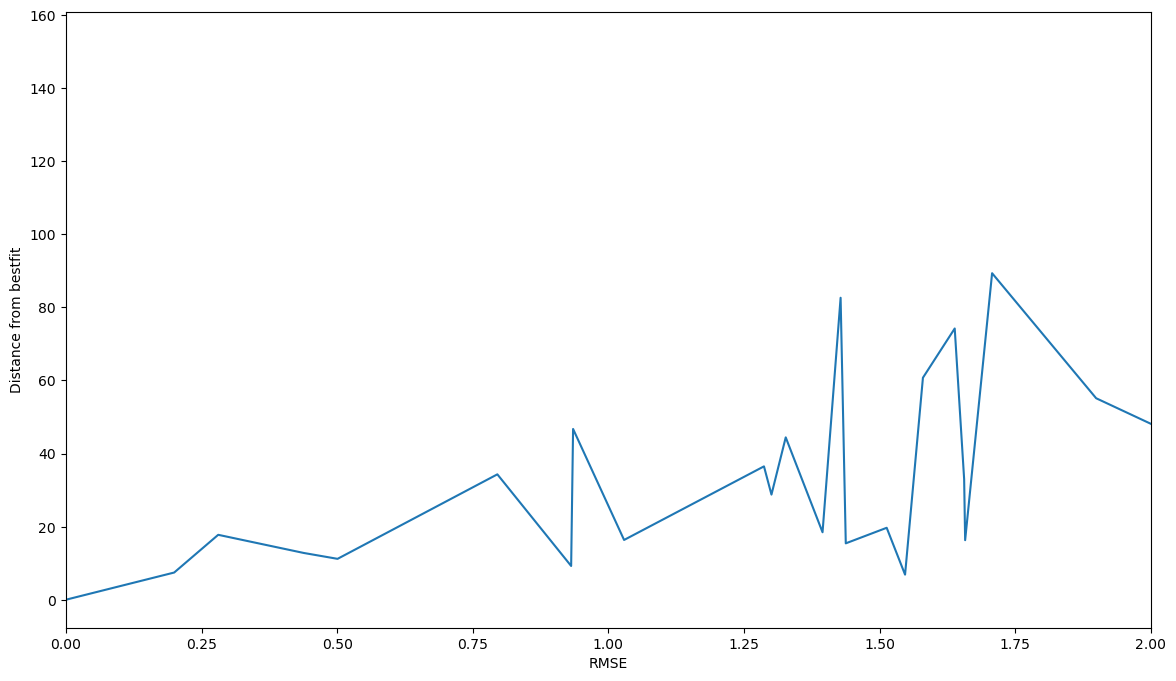

In [162]:
plt.figure(figsize=(14,8))
plt.plot(results_df["diff_rmse"],results_df["distance"])
plt.xlabel("RMSE")
plt.ylabel("Distance from bestfit")
plt.xlim(left=0,right =2)
plt.show()

In [166]:
results_df.iloc[:5,9:]

,num_leaves,max_depth,learning_rate,feature_fraction,bagging_fraction,bagging_freq,min_data_in_leaf,lambda_l1,lambda_l2,distance,diff_rmse
48,490,13,0.016721,0.670558,0.741874,5,38,4.976927,0.448540,0.000000,0.000000
49,487,15,0.016726,0.616370,0.741302,6,60,4.859805,0.010171,7.440197,0.199585
43,443,13,0.011314,0.742618,0.742482,5,63,2.375473,0.409208,17.766305,0.280762
44,461,12,0.012096,0.685314,0.733221,6,63,2.384828,0.588907,12.800777,0.438311
45,467,13,0.011934,0.658926,0.743618,5,62,0.311344,0.451673,11.189121,0.500739
